In [1]:
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [2]:
# ============================================================
# LOAD BEST CONFIG
# ============================================================

import json

# Open the file and parse its contents
with open('descriptornet_datasetA_bho/best_config.json', 'r') as file:
    best_configuration = json.load(file)
best_configuration

{'depth': 2,
 'width': 128,
 'activation': 'gelu',
 'lr': 0.0026820797458405802,
 'batch_size': 256}

In [3]:
# ============================================================
# CONFIG
# ============================================================
TRAIN_DIR    = "../datasetA_training_data"
TEST_DIR     = "../datasetA_testing_data"
NET2_WEIGHTS = "../physicsnet/physicsnet_pretrained.pt"
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
# --- Network 1 (trained) ---
N1_DEPTH = best_configuration["depth"]
N1_WIDTH = best_configuration["width"]
N1_ACT = best_configuration["activation"]


# --- Network 2 (frozen) ---
N2_DEPTH = 3
N2_WIDTH = 256
N2_ACT = "silu"
 
# --- Training ---
EPOCHS = 200
LR = best_configuration["lr"]
BATCH_SIZE = best_configuration["batch_size"]
N_RHO_INTEGRATION = 20 # 50
 
SEED = 0

In [4]:
# ============================================================
# DATA
# ============================================================
def load_dataset(data_dir, start_id=0):
    c = np.load(f"{data_dir}/c_release_matrix.npy")[start_id:]
    t = np.load(f"{data_dir}/t_release_matrix.npy")[start_id:]
    D0 = np.load(f"{data_dir}/D0_array.npy")[start_id:]
    eps = np.load(f"{data_dir}/epsilon_array.npy")[start_id:]
    tau = np.load(f"{data_dir}/tau_ort_array.npy")[start_id:]
    D_eff = np.load(f"{data_dir}/Deff_array.npy")[start_id:]
    R = np.load(f"{data_dir}/R_array.npy")[start_id:]
    return {"c": c, "t": t, "D0": D0, "eps": eps, "tau": tau,
            "D_eff": D_eff, "R": R, "N": c.shape[0], "T": c.shape[1]}
 
 
def make_tensors(ds, desc_mean, desc_std):
    desc_raw = np.stack([ds["eps"], ds["tau"], np.log10(ds["D0"])], axis=1)
    desc_norm = (desc_raw - desc_mean) / desc_std
    return {
        "desc": torch.tensor(desc_norm, dtype=torch.float32, device=DEVICE),
        "t": torch.tensor(ds["t"], dtype=torch.float32, device=DEVICE),
        "c": torch.tensor(ds["c"], dtype=torch.float32, device=DEVICE),
        "R": torch.tensor(ds["R"], dtype=torch.float32, device=DEVICE),
        "D_eff": torch.tensor(ds["D_eff"], dtype=torch.float32, device=DEVICE),
        "N": ds["N"], "T": ds["T"],
    }

In [5]:
# ============================================================
# NETWORKS
# ============================================================
def get_activation(name):
    return {"tanh": nn.Tanh(), "silu": nn.SiLU(), "gelu": nn.GELU()}[name.lower()]
 
 
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, depth, width, activation):
        super().__init__()
        layers = [nn.Linear(in_dim, width), get_activation(activation)]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), get_activation(activation)]
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
 
    def forward(self, x):
        return self.net(x)
 
 
class DescriptorNet(nn.Module):
    """Network 1 (trained): descriptors -> log10(D_eff in cm^2/s)."""
    def __init__(self, n_desc=3, depth=N1_DEPTH, width=N1_WIDTH,
                 activation=N1_ACT, log10_D_init=-10.0):
        super().__init__()
        self.mlp = MLP(n_desc, 1, depth, width, activation)
        final_linear = self.mlp.net[-1]
        # nn.init.zeros_(final_linear.weight)
        nn.init.constant_(final_linear.bias, log10_D_init)
 
    def forward(self, desc):
        return self.mlp(desc).squeeze(-1)
 
 
class PhysicsNet(nn.Module):
    """Network 2 (frozen): (rho, Fo) -> u(rho, Fo).
 
    IMPORTANT: this class must be structurally identical to the PhysicsNet
    in pretrain_net2.py, including the ansatz form, or load_state_dict will
    fail or silently load wrong weights.
    """
    def __init__(self, depth=N2_DEPTH, width=N2_WIDTH, activation=N2_ACT):
        super().__init__()
        self.mlp = MLP(2, 1, depth, width, activation)
 
    def forward(self, rho, Fo):
        x = torch.cat([rho**2, Fo], dim=1)
        raw = self.mlp(x)
        return (1.0 - rho**2) * raw          # hard BC: u(rho=1) = 0

In [6]:
# ============================================================
# BRIDGE + INTEGRATION
# ============================================================
def predicted_release(net2, D_eff, t_abs, R, n_rho=None):
    Fo = D_eff.view(-1, 1) * t_abs / (R.view(-1, 1) ** 2)   # (N, T)
    return crank_release_torch(Fo)


def crank_release_torch(Fo, n_terms=200):
    """Fractional release from Crank series. Fo: (N, T) tensor, grad flows through it."""
    n = torch.arange(1, n_terms + 1, device=Fo.device, dtype=Fo.dtype)  # (M,)
    exponent = -(n**2) * (torch.pi**2) * Fo.unsqueeze(-1)               # (N, T, M)
    series = torch.sum(torch.exp(exponent) / n**2, dim=-1)              # (N, T)
    return 1.0 - (6.0 / torch.pi**2) * series

In [7]:
# ============================================================
# TRAIN
# ============================================================
def main():
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    print(f"Device: {DEVICE}")
 
    # --- Data ---
    train_raw = load_dataset(TRAIN_DIR)
    test_raw = load_dataset(TEST_DIR)
    print(f"Train: {train_raw['N']} particles | Test: {test_raw['N']}")
 
    desc_raw_train = np.stack(
        [train_raw["eps"], train_raw["tau"], np.log10(train_raw["D0"])], axis=1
    )
    desc_mean = desc_raw_train.mean(axis=0)
    desc_std = desc_raw_train.std(axis=0)
 
    train = make_tensors(train_raw, desc_mean, desc_std)
    test = make_tensors(test_raw, desc_mean, desc_std)
 
    # --- Network 1: trained ---
    log10_D_init = float(np.mean(np.log10(train_raw["D_eff"])))
    # log10_D_init = -8.0
    print(f"Network 1 output bias init: log10(D) = {log10_D_init:.3f}")
    net1 = DescriptorNet(log10_D_init=log10_D_init).to(DEVICE)
 
    # # --- Network 2: load pre-trained weights, then FREEZE ---
    # net2 = PhysicsNet().to(DEVICE)
    # try:
    #     state = torch.load(NET2_WEIGHTS, map_location=DEVICE)
    #     net2.load_state_dict(state)
    # except Exception as e:
    #     raise RuntimeError(
    #         f"Failed to load {NET2_WEIGHTS}. The most likely cause is an "
    #         f"architecture mismatch: N2_DEPTH/N2_WIDTH/N2_ACT here must match "
    #         f"pretrain_net2.py exactly. Original error:\n{e}"
    #     )

    
    # # Freeze: parameters do not update. Graph still flows through net2.
    # for p in net2.parameters():
    #     p.requires_grad_(False)
    # net2.eval()   # frozen physics; eval mode (no dropout/BN here anyway)
 
    n1_params = sum(p.numel() for p in net1.parameters())
    # n2_params = sum(p.numel() for p in net2.parameters())
    print(f"Network 1 (trained): {n1_params:,} params")
    # print(f"Network 2 (FROZEN):  {n2_params:,} params")
 
    # Optimizer gets ONLY Network 1's parameters.
    optimizer = torch.optim.Adam(net1.parameters(), lr=LR)
    print("-" * 70)
 
    N_train = train["N"]
    n_batches = (N_train + BATCH_SIZE - 1) // BATCH_SIZE
 
    for epoch in range(EPOCHS):
        net1.train()
 
        perm = torch.randperm(N_train, device=DEVICE)
        epoch_data = 0.0
 
        for b in range(n_batches):
            idx = perm[b * BATCH_SIZE:(b + 1) * BATCH_SIZE]
 
            optimizer.zero_grad()
 
            log10_D = net1(train["desc"][idx])
            D_eff_pred = 10.0 ** log10_D
 
            release_pred = predicted_release(
                None, D_eff_pred, train["t"][idx], train["R"][idx]
            )
 
            loss_data = torch.mean((release_pred - train["c"][idx]) ** 2)
            loss_data.backward()
            grad_norm = sum(
                p.grad.norm().item()**2 
                for p in net1.parameters() 
                if p.grad is not None
            )**0.5

            
            torch.nn.utils.clip_grad_norm_(net1.parameters(), 1.0)
            optimizer.step()
 
            epoch_data += loss_data.item()
 
        epoch_data /= n_batches
 
        # --- Logging ---
        if epoch % 1 == 0 or epoch == EPOCHS - 1:
            net1.eval()
            with torch.no_grad():
                # D recovery error on train
                log_err_sum = 0.0
                for b in range(n_batches):
                    sl = slice(b * BATCH_SIZE, (b + 1) * BATCH_SIZE)
                    D_pred = 10.0 ** net1(train["desc"][sl])
                    D_true = train["D_eff"][sl]
                    log_err_sum += torch.sum(
                        torch.abs(torch.log10(D_pred) - torch.log10(D_true))
                    ).item()
                train_D_logerr = log_err_sum / N_train
 
                # D recovery error on test
                N_test = test["N"]
                n_tb = (N_test + BATCH_SIZE - 1) // BATCH_SIZE
                test_logerr_sum = 0.0
                test_data_sum = 0.0
                for b in range(n_tb):
                    sl = slice(b * BATCH_SIZE, (b + 1) * BATCH_SIZE)
                    D_pred = 10.0 ** net1(test["desc"][sl])
                    D_true = test["D_eff"][sl]
                    test_logerr_sum += torch.sum(
                        torch.abs(torch.log10(D_pred) - torch.log10(D_true))
                    ).item()
                    release_test = predicted_release(
                        None, D_pred, test["t"][sl], test["R"][sl]
                    )
                    test_data_sum += torch.sum(
                        (release_test - test["c"][sl]) ** 2
                    ).item()
                test_D_logerr = test_logerr_sum / N_test
                test_data = test_data_sum / (N_test * test["T"])
        
 
            print(
                f"epoch {epoch:5d} | "
                f"data {epoch_data:.3e} | "
                f"test_data {test_data:.3e} | "
                f"D log-err train {train_D_logerr:.4f} | "
                f"test {test_D_logerr:.4f} | "
                f"gradient {grad_norm:.4f}"
            )
 
    print("-" * 70)
    return net1, None

In [8]:
descriptornet, physicsnet = main()

Device: cuda
Train: 8192 particles | Test: 1024
Network 1 output bias init: log10(D) = -12.525
Network 1 (trained): 17,153 params
----------------------------------------------------------------------
epoch     0 | data 2.577e-03 | test_data 1.969e-04 | D log-err train 0.0245 | test 0.0245 | gradient 0.0056
epoch     1 | data 1.457e-04 | test_data 7.452e-05 | D log-err train 0.0175 | test 0.0175 | gradient 0.0036
epoch     2 | data 4.963e-05 | test_data 3.651e-05 | D log-err train 0.0113 | test 0.0113 | gradient 0.0013
epoch     3 | data 3.098e-05 | test_data 2.549e-05 | D log-err train 0.0092 | test 0.0092 | gradient 0.0014
epoch     4 | data 2.222e-05 | test_data 1.858e-05 | D log-err train 0.0076 | test 0.0077 | gradient 0.0009
epoch     5 | data 1.678e-05 | test_data 1.515e-05 | D log-err train 0.0071 | test 0.0071 | gradient 0.0007
epoch     6 | data 1.391e-05 | test_data 1.287e-05 | D log-err train 0.0068 | test 0.0069 | gradient 0.0011
epoch     7 | data 1.246e-05 | test_data 1.

In [9]:
train_raw = load_dataset(TRAIN_DIR)
test_raw = load_dataset(TEST_DIR)

desc_raw_train = np.stack(
    [train_raw["eps"], train_raw["tau"], np.log10(train_raw["D0"])], axis=1
)
desc_mean = desc_raw_train.mean(axis=0)
desc_std = desc_raw_train.std(axis=0)

train = make_tensors(train_raw, desc_mean, desc_std)
test = make_tensors(test_raw, desc_mean, desc_std)

In [10]:
log10_D_predicted = descriptornet(test["desc"]).detach().cpu().numpy()
log10_D_actual = np.log10(test["D_eff"].detach().cpu().numpy())

(<Figure size 340x340 with 1 Axes>,
 <Axes: xlabel='True $\\log_{10}(D_{\\mathrm{eff}})$', ylabel='Predicted $\\log_{10}(D_{\\mathrm{eff}})$'>)

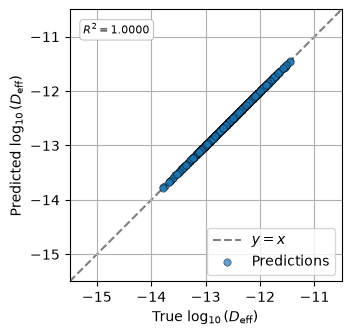

In [11]:
import numpy as np
from sklearn.metrics import r2_score

def parity_plot(y_true, y_pred, lo=-15.5, hi=-10.5, save=None):
    """Parity plot for log10(D_eff). Shared across Figs 6, 8, 9, 11."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    r2 = r2_score(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(3.4, 3.4), constrained_layout=True)

    ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--',
            zorder=1, label=r'$y = x$')                       # identity first, behind
    ax.scatter(y_true, y_pred, color='#1f77b4', alpha=0.7,
               edgecolor='black', linewidth=0.4, s=28,
               zorder=2, label='Predictions')

    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')                  # true 45° line
    ax.set_xlabel(r"True $\log_{10}(D_{\mathrm{eff}})$")
    ax.set_ylabel(r"Predicted $\log_{10}(D_{\mathrm{eff}})$")
    ax.grid(True)

    ax.text(0.05, 0.95, fr"$R^2 = {r2:.4f}$", transform=ax.transAxes,
            va='top', ha='left', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', lw=0.6))
    ax.legend(loc='lower right')

    if save:
        fig.savefig(save + ".pdf")
        fig.savefig(save + ".png", dpi=600)
    return fig, ax

# ---- Figure 6: Dataset A (synthetic) ----
parity_plot(log10_D_actual, log10_D_predicted, save="../plots/fig6_datasetA_parity")

# Plot release % vs actual time for different D and R values

In [14]:
def crank_release(t_s, D_cm2_s, R_cm, n_terms=50):
    """
    Fractional release at times t for diffusivity D and radius R.

    Internal units: t in seconds, R in cm, D in cm^2/s.

    Parameters
    ----------
    t_s : array_like
        Time in seconds (non-negative).
    D_cm2_s : float
        Effective diffusivity in cm^2/s (positive).
    R_cm : float
        Particle radius in cm (positive).
    n_terms : int
        Number of series terms. Default 50.

    Returns
    -------
    M_frac : ndarray
        Fractional release, clipped to [0, 1].
    """
    t_s = np.asarray(t_s, dtype=float)
    
    if D_cm2_s <= 0 or R_cm <= 0:
        raise ValueError(f"D and R must be positive (got D={D_cm2_s}, R={R_cm}).")

    # The Fourier number is dimensionless: (cm^2/s * s) / cm^2 = 1
    Fo = D_cm2_s * t_s / (R_cm ** 2)
    
    n = np.arange(1, n_terms + 1).reshape(-1, 1)
    Fo_row = Fo.reshape(1, -1)
    
    exponent = -(n ** 2) * (np.pi ** 2) * Fo_row
    series_sum = np.sum(np.exp(exponent) / (n ** 2), axis=0)

    M_frac = 1.0 - (6.0 / np.pi ** 2) * series_sum
    
    return np.clip(M_frac, 0.0, 1.0)

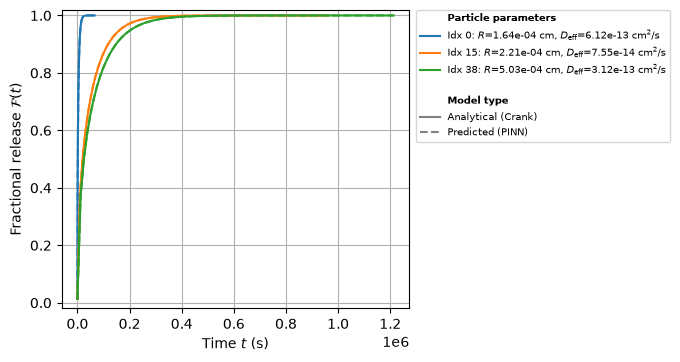

In [16]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torch
import numpy as np

indices_to_study = [0, 15, 38]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(6.5, 3.6))      # full width; a touch taller for the legend

particle_legend_elements = []
for i, studied_index in enumerate(indices_to_study):
    color = colors[i]
    R = test['R'][studied_index].item()
    D_eff_actual = test['D_eff'][studied_index].item()
    D_eff_predicted = 10 ** descriptornet(test['desc'][studied_index, :]).item()

    rho_grid = torch.tensor(np.linspace(0, 1, 100), device=DEVICE, dtype=torch.float32)
    Fo_values = np.linspace(0.00001, 1.5, 100)
    t_grid = Fo_values * R**2 / D_eff_predicted
    Fo_tensor = torch.tensor(Fo_values, device=DEVICE, dtype=torch.float32)

    release_predicted = crank_release(t_grid, D_eff_predicted, R, n_terms=200)
    release_actual = crank_release(t_grid, D_eff_actual, R, n_terms=50)
    rel_pred_np = release_predicted

    ax.plot(t_grid, release_actual, color=color, linestyle='-')    # analytical (solid)
    ax.plot(t_grid, rel_pred_np,   color=color, linestyle='--')    # prediction (dashed)

    label_text = (fr"Idx {studied_index}: $R$={R:.2e} cm, "
                  fr"$D_{{\mathrm{{eff}}}}$={D_eff_actual:.2e} cm$^2$/s")
    particle_legend_elements.append(
        Line2D([0], [0], color=color, linestyle='-', label=label_text)
    )

# ---- unified legend ----
style_legend_elements = [
    Line2D([0], [0], color='gray', linestyle='-',  label="Analytical (Crank)"),
    Line2D([0], [0], color='gray', linestyle='--', label="Predicted (PINN)"),
]
header_particles = Line2D([], [], color='none', label=r'$\bf{Particle\ parameters}$')
header_models    = Line2D([], [], color='none', label=r'$\bf{Model\ type}$')
spacer           = Line2D([], [], color='none', label=' ')
all_handles = [header_particles, *particle_legend_elements,
               spacer, header_models, *style_legend_elements]

ax.legend(handles=all_handles, loc='upper left', bbox_to_anchor=(1.02, 1.0),
          borderaxespad=0.0, fontsize=7)

# ---- axes ----
ax.set_xlabel(r"Time $t$ (s)")
ax.set_ylabel(r"Fractional release $\mathcal{F}(t)$")
ax.set_ylim(-0.02, 1.02)
ax.grid(True)

# reserve right margin so the SAVED width stays 6.5 in (external legend)
fig.subplots_adjust(left=0.085, right=0.62, top=0.96, bottom=0.13)

# fig.savefig("../plots/fig7_datasetA_releases.pdf")
# fig.savefig("../plots/fig7_datasetA_releases.png", dpi=600)
plt.show()